# Chapter 18: N-View Computational Methods

Source orientation: printed pages 434-457; PDF pages 452-475.

This chapter asks how a long set of image measurements becomes a reconstruction. The central objects are not just cameras and 3D points, but also the track matrix, projective depths, observation graph, and residual function. Each computational method below is tied to one inspection target: rank for factorization, sparsity for bundle adjustment, conditioning for projective factorization, and connectivity for sequence initialization.

The notebook uses synthetic measurements so the invariants are auditable. No textbook figures, screenshots, or page crops are used.

## Chapter Goal

Build a working mental model for N-view reconstruction methods:

- **Bundle adjustment** is nonlinear least squares over many cameras and many points. Its cost is local but its graph is sparse.
- **Affine factorization** turns complete centered tracks into a nearest rank-3 matrix.
- **Non-rigid factorization** keeps the same subspace idea but raises the rank bound to `3*l` for `l` basis shapes.
- **Projective factorization** needs projective depths before rank-4 truncation makes geometric sense.
- **Plane-based projective reconstruction** uses known plane-induced homographies to solve for the missing camera columns.
- **Sequence reconstruction** is an initialization strategy: track locally, merge or extend baselines, then bundle adjust globally.

## Computational Translation Guide

| Book object | Computational object in this notebook | What to inspect |
| --- | --- | --- |
| image measurements `x_ij` | arrays of per-camera point tracks plus a visibility mask | missing data affects bundle adjustment, but complete tracks are needed for direct SVD factorization |
| bundle adjustment | a sparse residual vector with camera-point dependencies | the normal matrix has block sparsity and the residual descends from a good initialization |
| affine reconstruction | centered `2m x n` measurement matrix `W` | singular values drop after the third value and the rank-3 approximation reprojection error is small |
| non-rigid shape basis | a `2m x n` matrix whose trajectories lie in a `3*l` subspace | singular values drop after `3*l`, not after 3 |
| projective depth `lambda_ij` | scalar weights multiplying homogeneous image points | correct depths make the projective track matrix rank 4; unit depths usually do not |
| plane homographies | known left `3 x 3` camera blocks `M_i` | a linear system solves the remaining columns `t_i` up to common scale |
| image sequence | an ordered graph of pair, triplet, and merge windows | local tracks must overlap enough to support a global initialization |

## Library Routing

| Chapter concept | Representation | Library | Why this route | Fallback |
| --- | --- | --- | --- | --- |
| bundle adjustment residuals | nonlinear least squares with a camera-point Jacobian pattern | `scipy.optimize`, `scipy.sparse` | the chapter is about large residual systems, so the solver and sparse structure should be visible | reduce to alternating least squares with NumPy |
| observation and sequence graphs | bipartite and path graphs | `networkx` | graph connectivity and block adjacency explain why missing data is acceptable for bundle adjustment but hard for direct factorization | draw the same edges manually with Matplotlib |
| affine and non-rigid factorization | SVD spectra and low-rank reconstructions | `numpy.linalg.svd`, Matplotlib | rank is the invariant; SVD is the algorithmic object | eigen-decomposition of `W W.T`, with worse conditioning |
| projective factorization | homogeneous track matrix, depth normalization, rank-4 spectrum | NumPy, Matplotlib | projective depths and isotropic normalization are numeric conditioning issues | use only unit depths as a deliberately bad baseline |
| 3D camera-track scene | interactive point and camera path view | Plotly | N-view geometry is spatial and benefits from rotation in the browser | static Matplotlib 3D scatter |
| projective-depth gauge | symbolic row/column scaling identity | SymPy | the row-column scale freedom is exact, so a symbolic check is clearer than a numeric example | a one-line algebraic derivation in markdown |

## Chapter-Specific Storyboard

| Visual | Concept | Artifact | Learner inspection target | Check |
| --- | --- | --- | --- | --- |
| N-view camera-track scene | many cameras observe the same 3D points | `interactive/n-view-camera-track-scene.html` | rotate the scene and connect camera centers to shared points | positive projective depths and nonempty observation graph |
| bundle sparsity and normal matrix | bundle adjustment remains large but sparse | `figures/bundle-adjustment-sparse-normal.png` | each residual touches one camera block and one point block | normal-pattern density is far below dense |
| affine factorization rank spectrum | centered affine tracks are rank 3 | `figures/affine-factorization-rank-spectrum.png` | the fourth singular value is noise-scale | rank-3 relative reconstruction error is small |
| non-rigid subspace rank | `l` basis shapes raise the rank limit to `3*l` | `figures/nonrigid-subspace-mode-rank.png` | the drop occurs after six singular values for two basis shapes | rank-6 gap is small |
| projective depth factorization | projective depths make rank-4 truncation meaningful | `figures/projective-depth-factorization.png` | correct depths create a rank-4 matrix; unit depths do not | fifth/fourth singular-value ratio separates the cases |
| residual descent and conditioning | optimization and normalization are diagnostics, not afterthoughts | `figures/residual-descent-conditioning.png` | residual decreases while normalized coordinates improve conditioning | final RMS is smaller and normalized condition is better |
| plane-homography translation system | plane-induced homographies leave only final camera columns unknown | `figures/plane-homography-translation-system.png` | sparsity shows each equation touches one point and one camera translation | linear null-space has dimension one |
| sequence initialization graph | local matching must become a global initialization | `figures/sequence-initialization-graph.png` | pairwise, triplet, and merge windows overlap | pair graph connected and neighboring triplets overlap in two frames |

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from scipy import sparse
from scipy.optimize import least_squares
from sympy import simplify, symbols

START_DIR = Path.cwd().resolve()
root_candidates = [START_DIR, START_DIR / "Multiple-View-Geometry-in-Computer-Vision"]
for parent in START_DIR.parents:
    root_candidates.extend([parent, parent / "Multiple-View-Geometry-in-Computer-Vision"])
for candidate in root_candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate the Multiple View Geometry book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

TOPIC = "chapter-18"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for directory in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(18)
artifact_paths: list[Path] = []
check_data: dict[str, object] = {}

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print(f"Book root: {BOOK_ROOT}")
print(f"Artifacts: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: Multiple-View-Geometry-in-Computer-Vision
Artifacts: artifacts/chapter-18


In [2]:
def save_fig(fig: plt.Figure, name: str, *, width: int = 860) -> Path:
    path = save_matplotlib(fig, TOPIC, "figures", name)
    plt.close(fig)
    artifact_paths.append(path)
    display_artifact(path, width=width)
    return path


def look_at_rotation(C: np.ndarray, target: np.ndarray | None = None) -> np.ndarray:
    if target is None:
        target = np.array([0.0, 0.0, 4.0])
    up = np.array([0.0, 1.0, 0.0])
    forward = target - np.asarray(C, dtype=float)
    forward = forward / np.linalg.norm(forward)
    right = np.cross(forward, up)
    right = right / np.linalg.norm(right)
    camera_up = np.cross(right, forward)
    camera_up = camera_up / np.linalg.norm(camera_up)
    return np.vstack([right, camera_up, forward])


def camera_matrix(K: np.ndarray, R: np.ndarray, C: np.ndarray) -> np.ndarray:
    return K @ np.column_stack([R, -R @ C])


def project_points(P: np.ndarray, X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    Xh = np.column_stack([X, np.ones(len(X))])
    projected = (P @ Xh.T).T
    return projected[:, :2] / projected[:, 2:3], projected[:, 2]


def isotropic_normalization_matrix(points_2d: np.ndarray) -> np.ndarray:
    center = points_2d.mean(axis=0)
    shifted = points_2d - center
    mean_distance = np.mean(np.sqrt(np.sum(shifted**2, axis=1)))
    scale = np.sqrt(2.0) / mean_distance
    return np.array([[scale, 0.0, -scale * center[0]], [0.0, scale, -scale * center[1]], [0.0, 0.0, 1.0]])


def make_projective_scene(n_points: int = 26) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    K = np.array([[720.0, 0.0, 320.0], [0.0, 720.0, 240.0], [0.0, 0.0, 1.0]])
    centers = np.array([
        [-1.6, 0.05, 0.00],
        [-0.8, -0.05, 0.10],
        [0.0, 0.03, -0.05],
        [0.8, 0.04, 0.08],
        [1.6, -0.02, 0.00],
    ])
    rotations = np.array([look_at_rotation(C) for C in centers])
    cameras = np.array([camera_matrix(K, R, C) for R, C in zip(rotations, centers)])
    points = rng.uniform([-1.0, -0.6, 3.1], [1.0, 0.7, 5.4], size=(n_points, 3))
    return K, centers, rotations, cameras, points


K, camera_centers_true, camera_rotations, projective_cameras, points_true = make_projective_scene()

observations: list[tuple[int, int, np.ndarray]] = []
image_tracks = np.full((len(projective_cameras), len(points_true), 2), np.nan)
projective_depths = np.zeros((len(projective_cameras), len(points_true)))
homogeneous_image_points = np.zeros((len(projective_cameras), len(points_true), 3))
for i, P in enumerate(projective_cameras):
    uv, depth = project_points(P, points_true)
    projective_depths[i] = depth
    homogeneous_image_points[i] = np.column_stack([uv, np.ones(len(points_true))])
    for j, point_uv in enumerate(uv):
        visible = bool(depth[j] > 0 and (j + i) % 7 != 0 and not (i == 4 and j % 5 == 1))
        if visible:
            measured = point_uv + rng.normal(0.0, 0.6, size=2)
            image_tracks[i, j] = measured
            observations.append((i, j, measured))

check_data["projective_scene"] = {
    "camera_count": int(len(projective_cameras)),
    "point_count": int(len(points_true)),
    "observation_count": int(len(observations)),
    "minimum_projective_depth": float(projective_depths.min()),
}
assert projective_depths.min() > 0
assert len(observations) > 0
print(check_data["projective_scene"])

{'camera_count': 5, 'point_count': 26, 'observation_count': 107, 'minimum_projective_depth': 3.070680320631203}


## N-View Scene: Cameras, Rays, And Tracks

The synthetic scene gives the rest of the notebook one shared data source. The Plotly artifact is deliberately spatial: rotate it and inspect how the same point cloud is seen from a path of camera centers. Bundle adjustment will use the partially missing noisy tracks; projective factorization will use the noiseless homogeneous tracks so the rank invariant can be checked exactly.

In [3]:
fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(
    x=points_true[:, 0], y=points_true[:, 1], z=points_true[:, 2],
    mode="markers", marker=dict(size=4, color="#1f77b4"), name="3D points",
))
fig3d.add_trace(go.Scatter3d(
    x=camera_centers_true[:, 0], y=camera_centers_true[:, 1], z=camera_centers_true[:, 2],
    mode="lines+markers", marker=dict(size=5, color="#d62728"), line=dict(color="#d62728", width=4),
    name="camera path",
))
for cam_id, C in enumerate(camera_centers_true):
    for point_id in range(0, len(points_true), 6):
        X = points_true[point_id]
        fig3d.add_trace(go.Scatter3d(
            x=[C[0], X[0]], y=[C[1], X[1]], z=[C[2], X[2]],
            mode="lines", line=dict(color="rgba(80,80,80,0.25)", width=2),
            showlegend=False,
        ))
fig3d.update_layout(
    title="N-view camera path and shared 3D tracks",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"),
    margin=dict(l=0, r=0, t=40, b=0),
)
scene_path = save_plotly_html(fig3d, TOPIC, "interactive", "n-view-camera-track-scene.html")
artifact_paths.append(scene_path)
display_artifact(scene_path, width=920, height=620)

.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Bundle Adjustment: Sparse Residuals, Not A Dense Monolith

A full projective bundle adjustment has camera, point, and sometimes calibration parameters. To keep the example small but faithful, this lab fixes intrinsics and rotations, fixes the first two camera centers as a gauge choice, and adjusts the remaining camera centers together with all 3D points. Each image residual depends on exactly one camera block and one point block, which is why large bundle adjustment systems are handled with sparse methods.

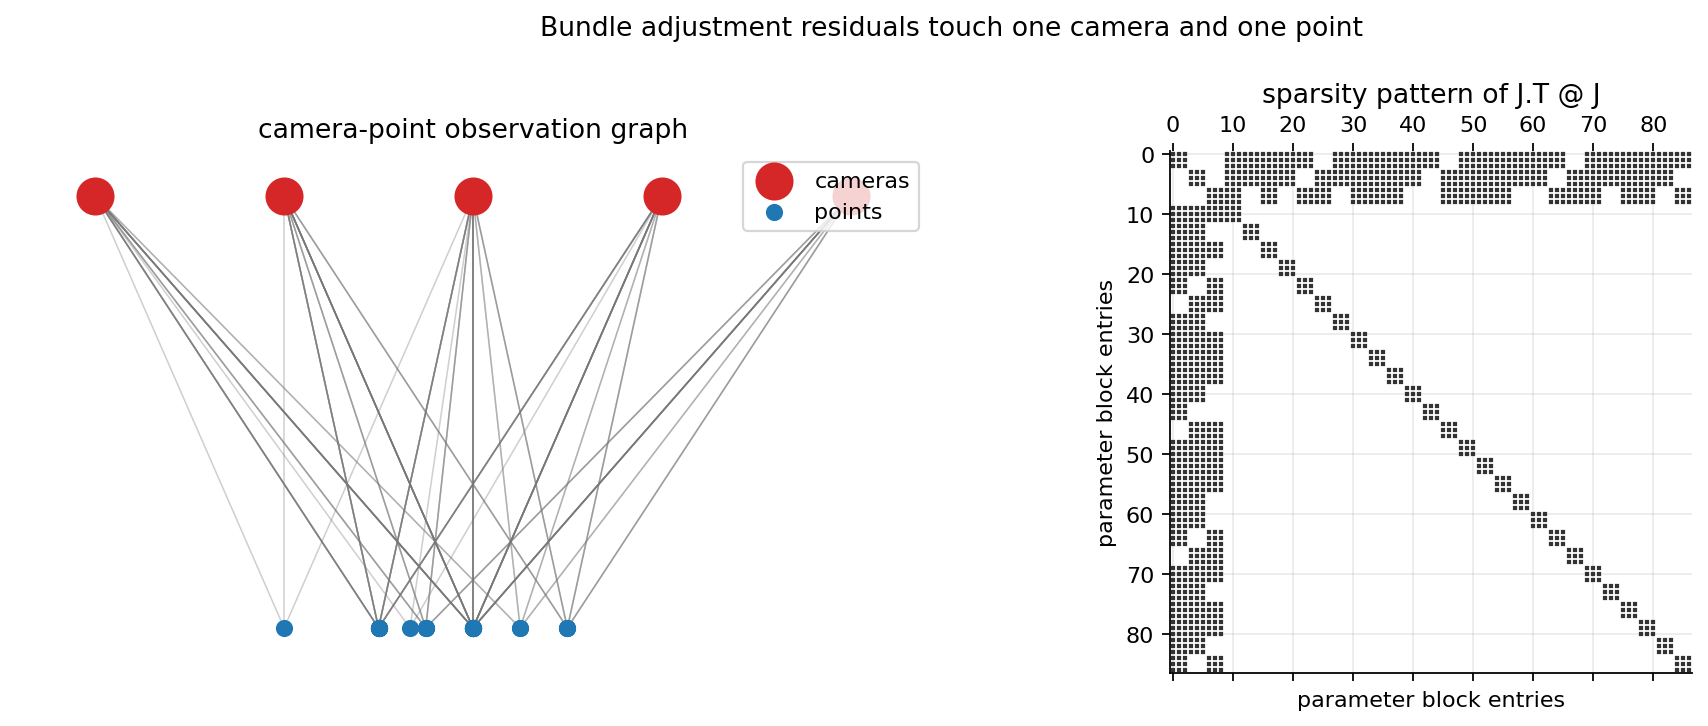

{'initial_rms_pixels': 36.47813601247967, 'final_rms_pixels': 0.501265472004811, 'least_squares_evaluations': 6, 'jacobian_shape': [214, 87], 'normal_pattern_density': 0.18192627824019025, 'observation_graph_connected': True}


In [4]:
fixed_camera_ids = {0, 1}
variable_camera_ids = [i for i in range(len(projective_cameras)) if i not in fixed_camera_ids]
variable_camera_lookup = {camera_id: k for k, camera_id in enumerate(variable_camera_ids)}


def pack_bundle_params(centers: np.ndarray, points: np.ndarray) -> np.ndarray:
    return np.r_[centers[variable_camera_ids].ravel(), points.ravel()]


def unpack_bundle_params(params: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centers = camera_centers_true.copy()
    split = 3 * len(variable_camera_ids)
    centers[variable_camera_ids] = params[:split].reshape(len(variable_camera_ids), 3)
    points = params[split:].reshape(len(points_true), 3)
    return centers, points


def bundle_residuals(params: np.ndarray) -> np.ndarray:
    centers, points = unpack_bundle_params(params)
    residual_vector: list[float] = []
    for camera_id, point_id, measured in observations:
        P = camera_matrix(K, camera_rotations[camera_id], centers[camera_id])
        predicted, _ = project_points(P, points[[point_id]])
        residual_vector.extend(predicted[0] - measured)
    return np.asarray(residual_vector)


initial_centers = camera_centers_true.copy()
initial_centers[variable_camera_ids] += rng.normal(0.0, 0.12, size=(len(variable_camera_ids), 3))
initial_points = points_true + rng.normal(0.0, 0.15, size=points_true.shape)
initial_params = pack_bundle_params(initial_centers, initial_points)
initial_residual = bundle_residuals(initial_params)

bundle_cost_history: list[float] = []


def residuals_with_history(params: np.ndarray) -> np.ndarray:
    residual = bundle_residuals(params)
    bundle_cost_history.append(float(0.5 * residual @ residual))
    return residual


bundle_result = least_squares(
    residuals_with_history,
    initial_params,
    max_nfev=80,
    x_scale="jac",
    ftol=1e-10,
    xtol=1e-10,
    gtol=1e-10,
)
final_residual = bundle_residuals(bundle_result.x)
rms_initial = float(np.sqrt(np.mean(initial_residual**2)))
rms_final = float(np.sqrt(np.mean(final_residual**2)))
running_best_rms = np.sqrt(2.0 * np.minimum.accumulate(bundle_cost_history) / len(initial_residual))

descent_path = save_csv(
    [{"evaluation": k, "running_best_rms_pixels": float(value)} for k, value in enumerate(running_best_rms)],
    TOPIC,
    "tables",
    "bundle-adjustment-descent.csv",
)
artifact_paths.append(descent_path)

n_variables = len(initial_params)
n_residuals = len(initial_residual)
pattern_rows: list[int] = []
pattern_cols: list[int] = []
for observation_id, (camera_id, point_id, _) in enumerate(observations):
    residual_rows = [2 * observation_id, 2 * observation_id + 1]
    if camera_id in variable_camera_lookup:
        col0 = 3 * variable_camera_lookup[camera_id]
        for row in residual_rows:
            pattern_rows.extend([row] * 3)
            pattern_cols.extend(range(col0, col0 + 3))
    point_col0 = 3 * len(variable_camera_ids) + 3 * point_id
    for row in residual_rows:
        pattern_rows.extend([row] * 3)
        pattern_cols.extend(range(point_col0, point_col0 + 3))

jacobian_pattern = sparse.coo_matrix(
    (np.ones(len(pattern_rows), dtype=bool), (pattern_rows, pattern_cols)),
    shape=(n_residuals, n_variables),
).tocsr()
normal_pattern = (jacobian_pattern.T @ jacobian_pattern).astype(bool)
normal_density = float(normal_pattern.nnz / (n_variables * n_variables))

observation_graph = nx.Graph()
for camera_id in range(len(projective_cameras)):
    observation_graph.add_node(f"C{camera_id}", bipartite="camera")
for point_id in range(len(points_true)):
    observation_graph.add_node(f"X{point_id}", bipartite="point")
for camera_id, point_id, _ in observations:
    observation_graph.add_edge(f"C{camera_id}", f"X{point_id}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
positions = {f"C{i}": (i, 1.0) for i in range(len(projective_cameras))}
for point_id in range(len(points_true)):
    visible_cameras = [camera_id for camera_id, pid, _ in observations if pid == point_id]
    x_position = np.mean(visible_cameras) if visible_cameras else 0.0
    positions[f"X{point_id}"] = (x_position, 0.0)
nx.draw_networkx_edges(observation_graph, positions, ax=axes[0], alpha=0.35, width=0.7, edge_color="#777777")
nx.draw_networkx_nodes(
    observation_graph,
    positions,
    nodelist=[f"C{i}" for i in range(len(projective_cameras))],
    node_color="#d62728",
    node_size=260,
    ax=axes[0],
    label="cameras",
)
nx.draw_networkx_nodes(
    observation_graph,
    positions,
    nodelist=[f"X{i}" for i in range(len(points_true))],
    node_color="#1f77b4",
    node_size=45,
    ax=axes[0],
    label="points",
)
axes[0].set_title("camera-point observation graph")
axes[0].set_axis_off()
axes[0].legend(loc="upper right")
axes[1].spy(normal_pattern, markersize=1.2, color="#333333")
axes[1].set_title("sparsity pattern of J.T @ J")
axes[1].set_xlabel("parameter block entries")
axes[1].set_ylabel("parameter block entries")
fig.suptitle("Bundle adjustment residuals touch one camera and one point")
fig.tight_layout()
bundle_path = save_fig(fig, "bundle-adjustment-sparse-normal.png", width=920)

check_data["bundle_adjustment"] = {
    "initial_rms_pixels": rms_initial,
    "final_rms_pixels": rms_final,
    "least_squares_evaluations": int(bundle_result.nfev),
    "jacobian_shape": [int(n_residuals), int(n_variables)],
    "normal_pattern_density": normal_density,
    "observation_graph_connected": bool(nx.is_connected(observation_graph)),
}
print(check_data["bundle_adjustment"])

## Affine Factorization: Center, Stack, Truncate

Affine cameras map centroids to centroids. After subtracting the centroid in every image, the translations disappear and the complete track matrix `W` should be a product of a `2m x 3` motion matrix and a `3 x n` structure matrix. The closest noisy version is therefore obtained by truncating the SVD to rank 3.

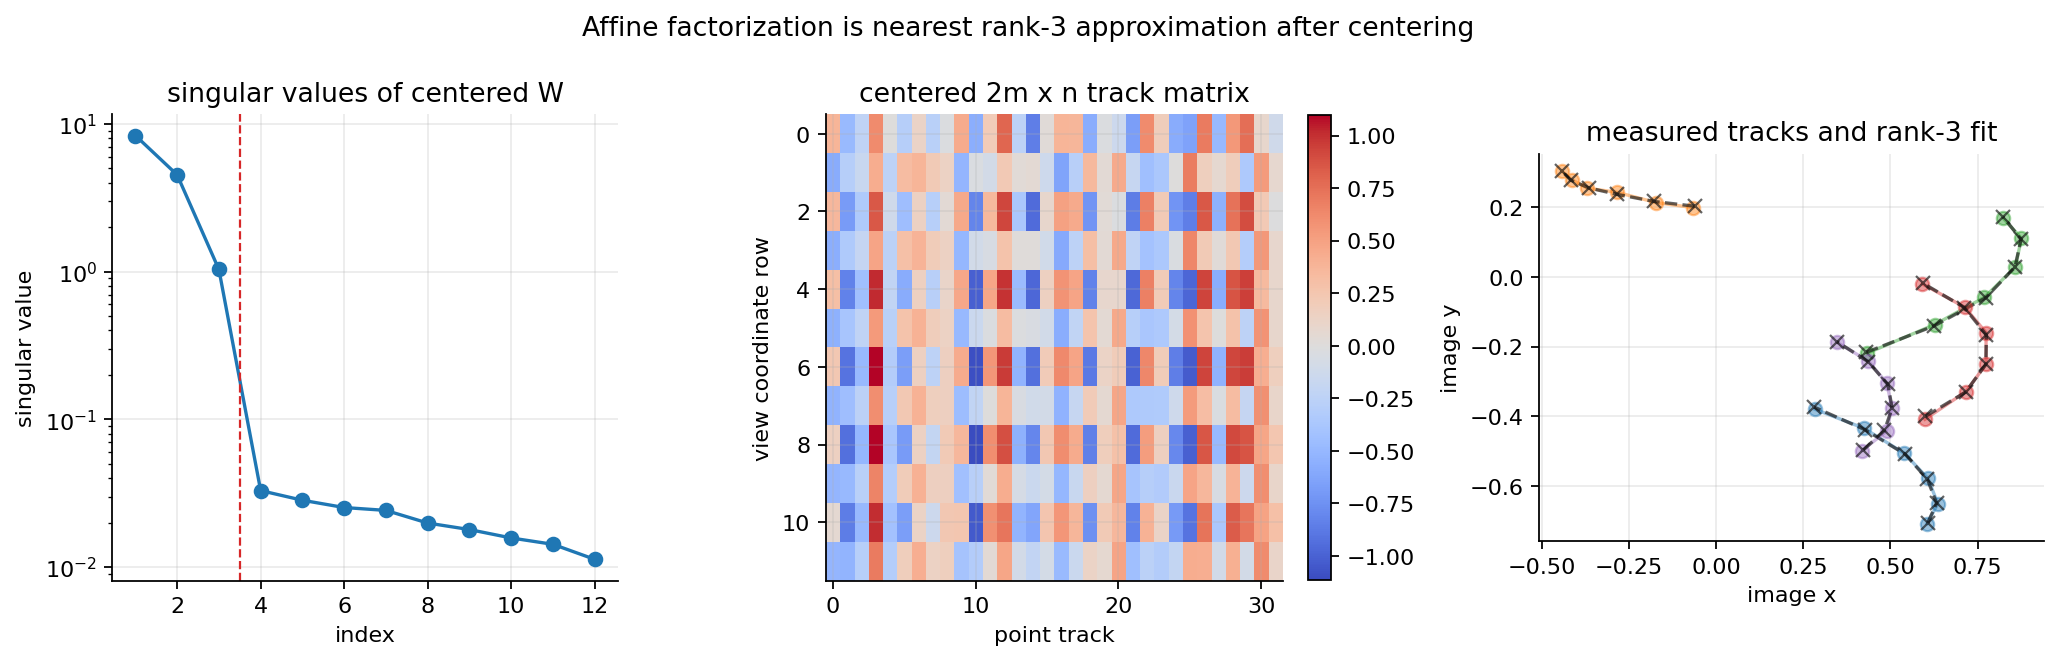

{'measurement_matrix_shape': [12, 32], 'fourth_over_third_singular_value': 0.03183905042824475, 'rank3_relative_frobenius_error': 0.006954641830260398}


In [5]:
affine_rng = np.random.default_rng(1801)
affine_view_count = 6
affine_point_count = 32
affine_points = affine_rng.uniform([-1.0, -0.8, -0.5], [1.0, 0.8, 0.7], size=(affine_point_count, 3))
affine_points -= affine_points.mean(axis=0)
affine_tracks = []
for theta in np.linspace(-0.7, 0.7, affine_view_count):
    linear_part = np.array([
        [np.cos(theta), 0.0, np.sin(theta)],
        [0.2 * np.sin(theta), 1.0, 0.1 * np.cos(theta)],
    ]) @ np.diag([1.1, 0.9, 0.7])
    translation = np.array([0.3 * np.cos(theta), 0.2 * np.sin(theta)])
    affine_tracks.append(affine_points @ linear_part.T + translation + affine_rng.normal(0.0, 0.004, size=(affine_point_count, 2)))
affine_tracks = np.asarray(affine_tracks)
affine_centroids = affine_tracks.mean(axis=1, keepdims=True)
affine_centered = affine_tracks - affine_centroids
W_affine = np.vstack([affine_centered[i].T for i in range(affine_view_count)])
U_affine, singular_affine, Vt_affine = np.linalg.svd(W_affine, full_matrices=False)
W_affine_rank3 = (U_affine[:, :3] * singular_affine[:3]) @ Vt_affine[:3]
affine_tracks_rank3 = np.asarray([
    W_affine_rank3[2 * i:2 * i + 2].T + affine_centroids[i, 0]
    for i in range(affine_view_count)
])
affine_rank_gap = float(singular_affine[3] / singular_affine[2])
affine_relative_error = float(np.linalg.norm(W_affine - W_affine_rank3) / np.linalg.norm(W_affine))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].semilogy(np.arange(1, len(singular_affine) + 1), singular_affine, "o-", color="#1f77b4")
axes[0].axvline(3.5, color="#d62728", linestyle="--", linewidth=1)
axes[0].set_title("singular values of centered W")
axes[0].set_xlabel("index")
axes[0].set_ylabel("singular value")
im = axes[1].imshow(W_affine, aspect="auto", cmap="coolwarm")
axes[1].set_title("centered 2m x n track matrix")
axes[1].set_xlabel("point track")
axes[1].set_ylabel("view coordinate row")
fig.colorbar(im, ax=axes[1], fraction=0.046)
for point_id in [0, 5, 11, 17, 23]:
    axes[2].plot(affine_tracks[:, point_id, 0], affine_tracks[:, point_id, 1], "o-", alpha=0.45)
    axes[2].plot(affine_tracks_rank3[:, point_id, 0], affine_tracks_rank3[:, point_id, 1], "x--", color="#111111", alpha=0.65)
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title("measured tracks and rank-3 fit")
axes[2].set_xlabel("image x")
axes[2].set_ylabel("image y")
fig.suptitle("Affine factorization is nearest rank-3 approximation after centering")
fig.tight_layout()
affine_path = save_fig(fig, "affine-factorization-rank-spectrum.png", width=940)

check_data["affine_factorization"] = {
    "measurement_matrix_shape": [int(v) for v in W_affine.shape],
    "fourth_over_third_singular_value": affine_rank_gap,
    "rank3_relative_frobenius_error": affine_relative_error,
}
print(check_data["affine_factorization"])

## Non-Rigid Factorization: More Shape Modes, Larger Subspace

For a deforming object represented by `l` basis shapes, each trajectory lives in a `3*l` dimensional subspace. This is not the same as saying the object is rigid in a higher-dimensional world; the motion matrix must still have repeated camera blocks. The visual below isolates the reliable part of the claim: the rank bound shifts from 3 to 6 when two basis shapes are active.

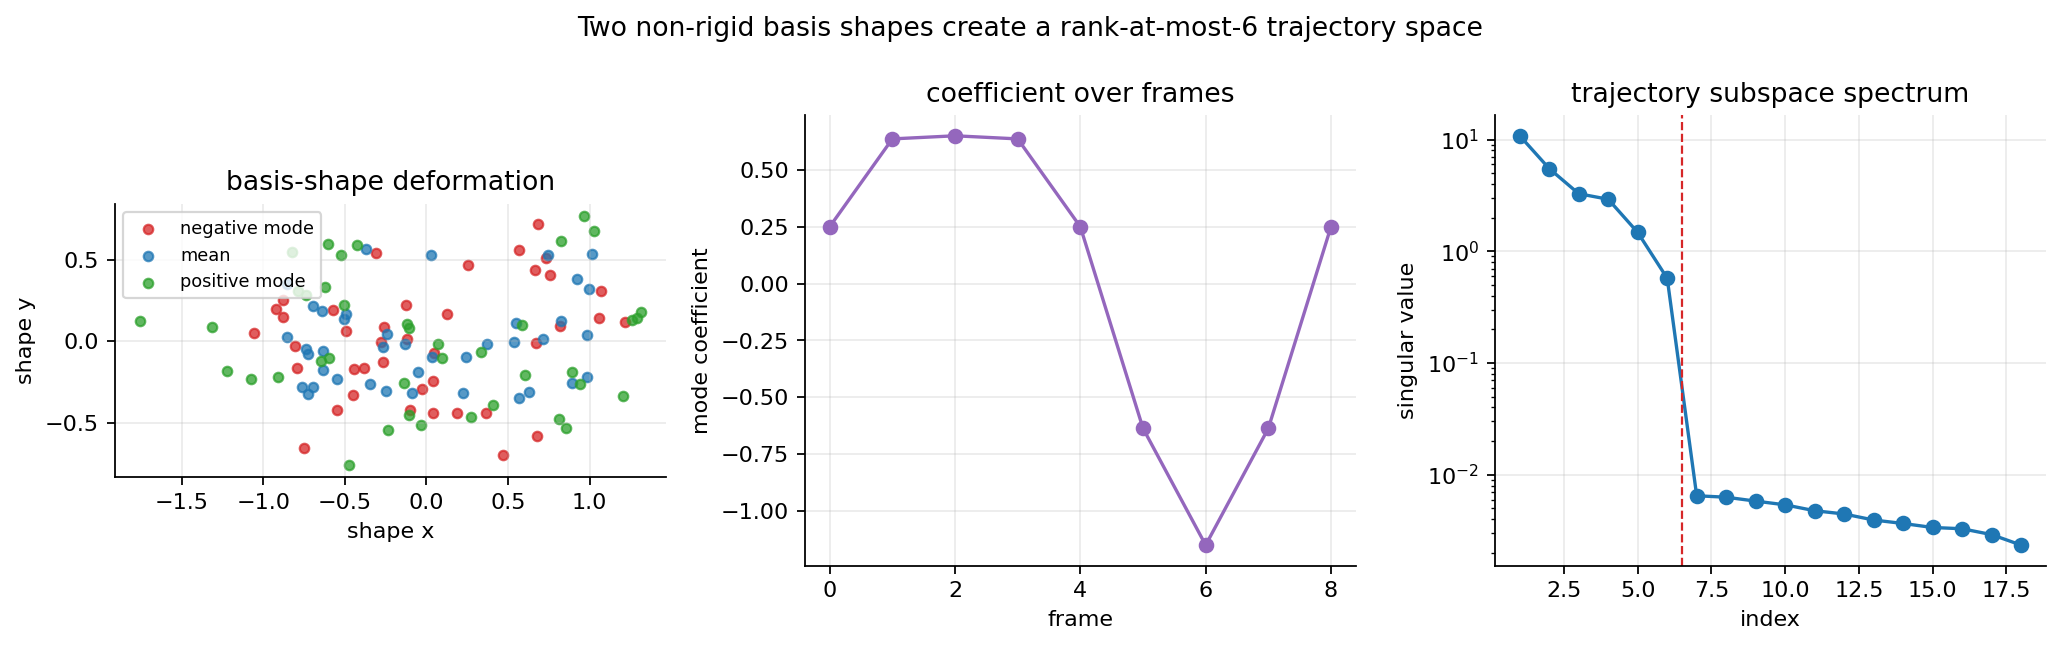

{'basis_shape_count': 2, 'rank_limit': 6, 'seventh_over_sixth_singular_value': 0.011295998158593034}


In [6]:
nonrigid_rng = np.random.default_rng(1802)
nonrigid_view_count = 9
nonrigid_point_count = 40
basis_count = 2
base_shape = nonrigid_rng.uniform([-1.0, -0.5, -0.3], [1.0, 0.5, 0.4], size=(nonrigid_point_count, 3))
base_shape -= base_shape.mean(axis=0)
mode_shape = nonrigid_rng.normal(0.0, 0.3, size=(nonrigid_point_count, 3))
mode_shape -= mode_shape.mean(axis=0)
nonrigid_tracks = []
mode_coefficients = []
for frame, theta in enumerate(np.linspace(-0.8, 0.8, nonrigid_view_count)):
    alpha = 0.9 * np.sin(frame / (nonrigid_view_count - 1) * 2.0 * np.pi) + 0.25 * np.cos(frame / (nonrigid_view_count - 1) * 4.0 * np.pi)
    mode_coefficients.append(alpha)
    shape = base_shape + alpha * mode_shape
    affine_camera = np.array([
        [np.cos(theta), 0.1 * np.sin(theta), np.sin(theta)],
        [0.15 * np.sin(theta), 1.0, 0.2 * np.cos(theta)],
    ])
    nonrigid_tracks.append(shape @ affine_camera.T + nonrigid_rng.normal(0.0, 0.0008, size=(nonrigid_point_count, 2)))
nonrigid_tracks = np.asarray(nonrigid_tracks)
nonrigid_centered = nonrigid_tracks - nonrigid_tracks.mean(axis=1, keepdims=True)
W_nonrigid = np.vstack([nonrigid_centered[i].T for i in range(nonrigid_view_count)])
singular_nonrigid = np.linalg.svd(W_nonrigid, compute_uv=False)
rank_limit = 3 * basis_count
nonrigid_rank_gap = float(singular_nonrigid[rank_limit] / singular_nonrigid[rank_limit - 1])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.1))
for alpha, color, label in [(-1.0, "#d62728", "negative mode"), (0.0, "#1f77b4", "mean"), (1.0, "#2ca02c", "positive mode")]:
    shape = base_shape + alpha * mode_shape
    axes[0].scatter(shape[:, 0], shape[:, 1], s=18, alpha=0.75, color=color, label=label)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("basis-shape deformation")
axes[0].set_xlabel("shape x")
axes[0].set_ylabel("shape y")
axes[0].legend(fontsize=8)
axes[1].plot(mode_coefficients, "o-", color="#9467bd")
axes[1].set_title("coefficient over frames")
axes[1].set_xlabel("frame")
axes[1].set_ylabel("mode coefficient")
axes[2].semilogy(np.arange(1, len(singular_nonrigid) + 1), singular_nonrigid, "o-", color="#1f77b4")
axes[2].axvline(rank_limit + 0.5, color="#d62728", linestyle="--", linewidth=1)
axes[2].set_title("trajectory subspace spectrum")
axes[2].set_xlabel("index")
axes[2].set_ylabel("singular value")
fig.suptitle("Two non-rigid basis shapes create a rank-at-most-6 trajectory space")
fig.tight_layout()
nonrigid_path = save_fig(fig, "nonrigid-subspace-mode-rank.png", width=940)

check_data["nonrigid_factorization"] = {
    "basis_shape_count": int(basis_count),
    "rank_limit": int(rank_limit),
    "seventh_over_sixth_singular_value": nonrigid_rank_gap,
}
print(check_data["nonrigid_factorization"])

## Projective Factorization: Rank 4 Needs Depths

Projective image coordinates are scale classes. The equation `lambda_ij x_ij = P_i X_j` becomes a rank-4 factorization only after the correct projective depths are applied. The practical difficulty is that those depths are unknown. This visual compares three matrices: correct depths, unit depths, and correct depths after isotropic image normalization.

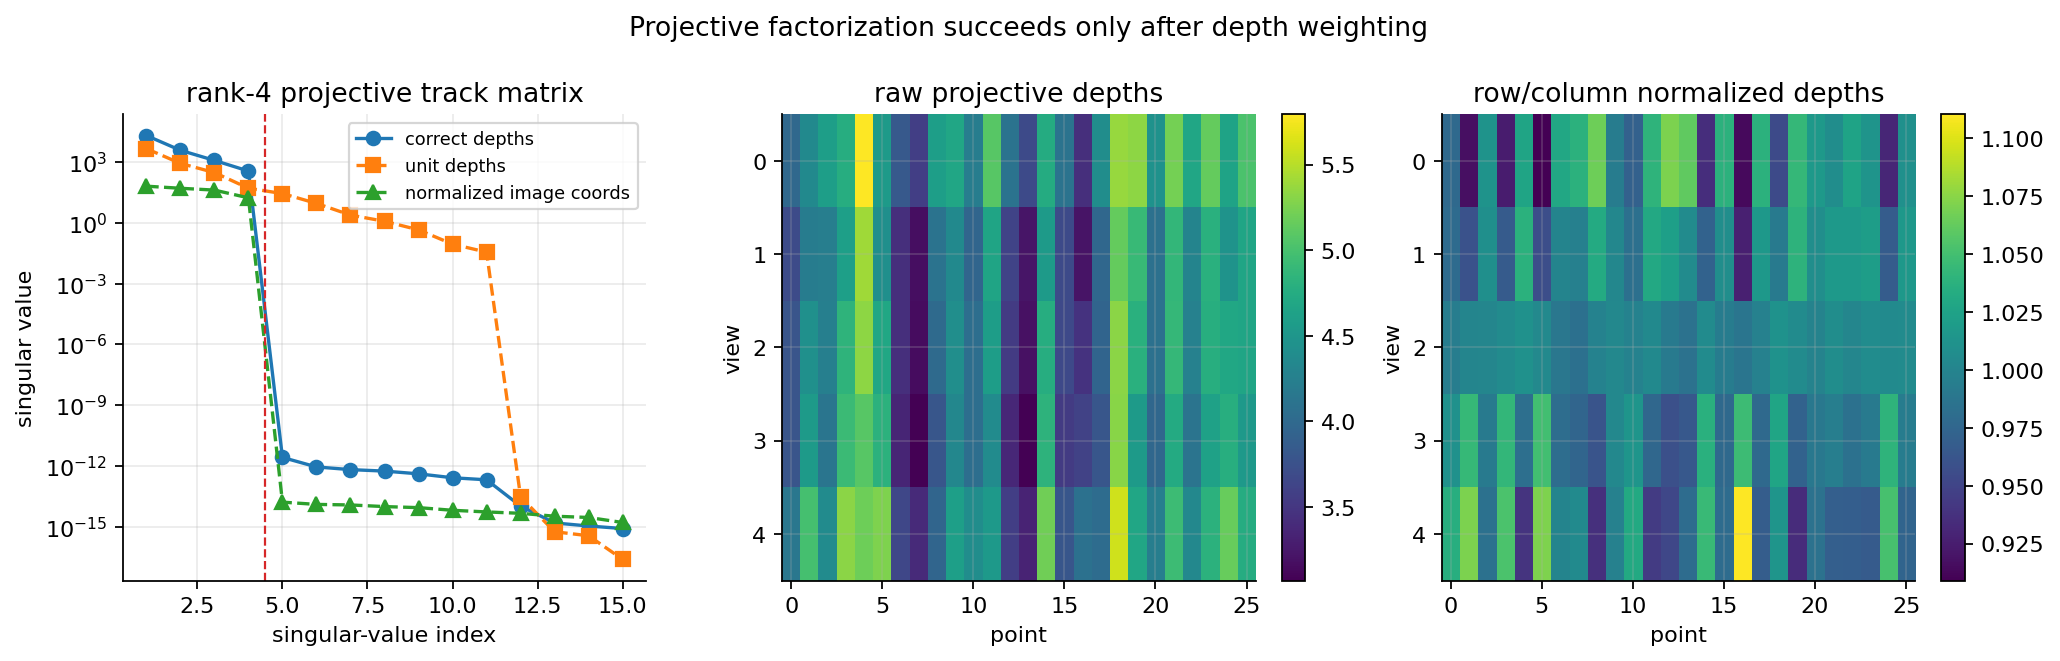

{'correct_depth_fifth_over_fourth_singular_value': 7.282808870675528e-15, 'unit_depth_fifth_over_fourth_singular_value': 0.5444203056434009, 'raw_correct_depth_condition_s1_over_s4': 56.666936298118834, 'normalized_correct_depth_condition_s1_over_s4': 3.762757436470001, 'unit_depth_condition_s1_over_s4': 90.06162913497678, 'depth_cv_before_row_column_normalization': 0.1423470316845392, 'depth_cv_after_row_column_normalization': 0.0353877079273186}


In [7]:
projective_view_count, projective_point_count = projective_depths.shape
W_projective_depth = np.vstack([
    (projective_depths[i, :, None] * homogeneous_image_points[i]).T
    for i in range(projective_view_count)
])
W_projective_unit = np.vstack([homogeneous_image_points[i].T for i in range(projective_view_count)])
normalized_homogeneous_points = []
for i in range(projective_view_count):
    T = isotropic_normalization_matrix(homogeneous_image_points[i, :, :2])
    normalized_homogeneous_points.append((T @ homogeneous_image_points[i].T).T)
normalized_homogeneous_points = np.asarray(normalized_homogeneous_points)
W_projective_normalized = np.vstack([
    (projective_depths[i, :, None] * normalized_homogeneous_points[i]).T
    for i in range(projective_view_count)
])

singular_depth = np.linalg.svd(W_projective_depth, compute_uv=False)
singular_unit = np.linalg.svd(W_projective_unit, compute_uv=False)
singular_normalized = np.linalg.svd(W_projective_normalized, compute_uv=False)
rank4_gap_correct = float(singular_depth[4] / singular_depth[3])
rank4_gap_unit = float(singular_unit[4] / singular_unit[3])
condition_correct = float(singular_depth[0] / singular_depth[3])
condition_normalized = float(singular_normalized[0] / singular_normalized[3])
condition_unit = float(singular_unit[0] / singular_unit[3])

depth_matrix_normalized = projective_depths.copy()
for _ in range(12):
    depth_matrix_normalized = depth_matrix_normalized / np.sqrt(np.mean(depth_matrix_normalized**2, axis=1, keepdims=True))
    depth_matrix_normalized = depth_matrix_normalized / np.sqrt(np.mean(depth_matrix_normalized**2, axis=0, keepdims=True))
depth_cv_before = float(np.std(projective_depths) / np.mean(projective_depths))
depth_cv_after = float(np.std(depth_matrix_normalized) / np.mean(depth_matrix_normalized))

spectrum_path = save_csv(
    [
        {
            "index": int(k + 1),
            "correct_depths": float(singular_depth[k]) if k < len(singular_depth) else None,
            "unit_depths": float(singular_unit[k]) if k < len(singular_unit) else None,
            "normalized_image_coordinates": float(singular_normalized[k]) if k < len(singular_normalized) else None,
        }
        for k in range(min(14, len(singular_depth)))
    ],
    TOPIC,
    "tables",
    "projective-factorization-spectrum.csv",
)
artifact_paths.append(spectrum_path)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].semilogy(np.arange(1, len(singular_depth) + 1), singular_depth, "o-", label="correct depths")
axes[0].semilogy(np.arange(1, len(singular_unit) + 1), singular_unit, "s--", label="unit depths")
axes[0].semilogy(np.arange(1, len(singular_normalized) + 1), singular_normalized, "^--", label="normalized image coords")
axes[0].axvline(4.5, color="#d62728", linestyle="--", linewidth=1)
axes[0].set_title("rank-4 projective track matrix")
axes[0].set_xlabel("singular-value index")
axes[0].set_ylabel("singular value")
axes[0].legend(fontsize=8)
im0 = axes[1].imshow(projective_depths, aspect="auto", cmap="viridis")
axes[1].set_title("raw projective depths")
axes[1].set_xlabel("point")
axes[1].set_ylabel("view")
fig.colorbar(im0, ax=axes[1], fraction=0.046)
im1 = axes[2].imshow(depth_matrix_normalized, aspect="auto", cmap="viridis")
axes[2].set_title("row/column normalized depths")
axes[2].set_xlabel("point")
axes[2].set_ylabel("view")
fig.colorbar(im1, ax=axes[2], fraction=0.046)
fig.suptitle("Projective factorization succeeds only after depth weighting")
fig.tight_layout()
projective_path = save_fig(fig, "projective-depth-factorization.png", width=940)

check_data["projective_factorization"] = {
    "correct_depth_fifth_over_fourth_singular_value": rank4_gap_correct,
    "unit_depth_fifth_over_fourth_singular_value": rank4_gap_unit,
    "raw_correct_depth_condition_s1_over_s4": condition_correct,
    "normalized_correct_depth_condition_s1_over_s4": condition_normalized,
    "unit_depth_condition_s1_over_s4": condition_unit,
    "depth_cv_before_row_column_normalization": depth_cv_before,
    "depth_cv_after_row_column_normalization": depth_cv_after,
}
print(check_data["projective_factorization"])

## Residual Descent And Conditioning

The chapter repeatedly warns that the algebraic matrix is not automatically the geometric error. Two diagnostics are paired here. The first tracks the best reprojection RMS reached by the bundle-adjustment solve. The second shows why isotropic image normalization matters before a homogeneous SVD: the same rank-4 object has a much smaller effective condition number after coordinate normalization.

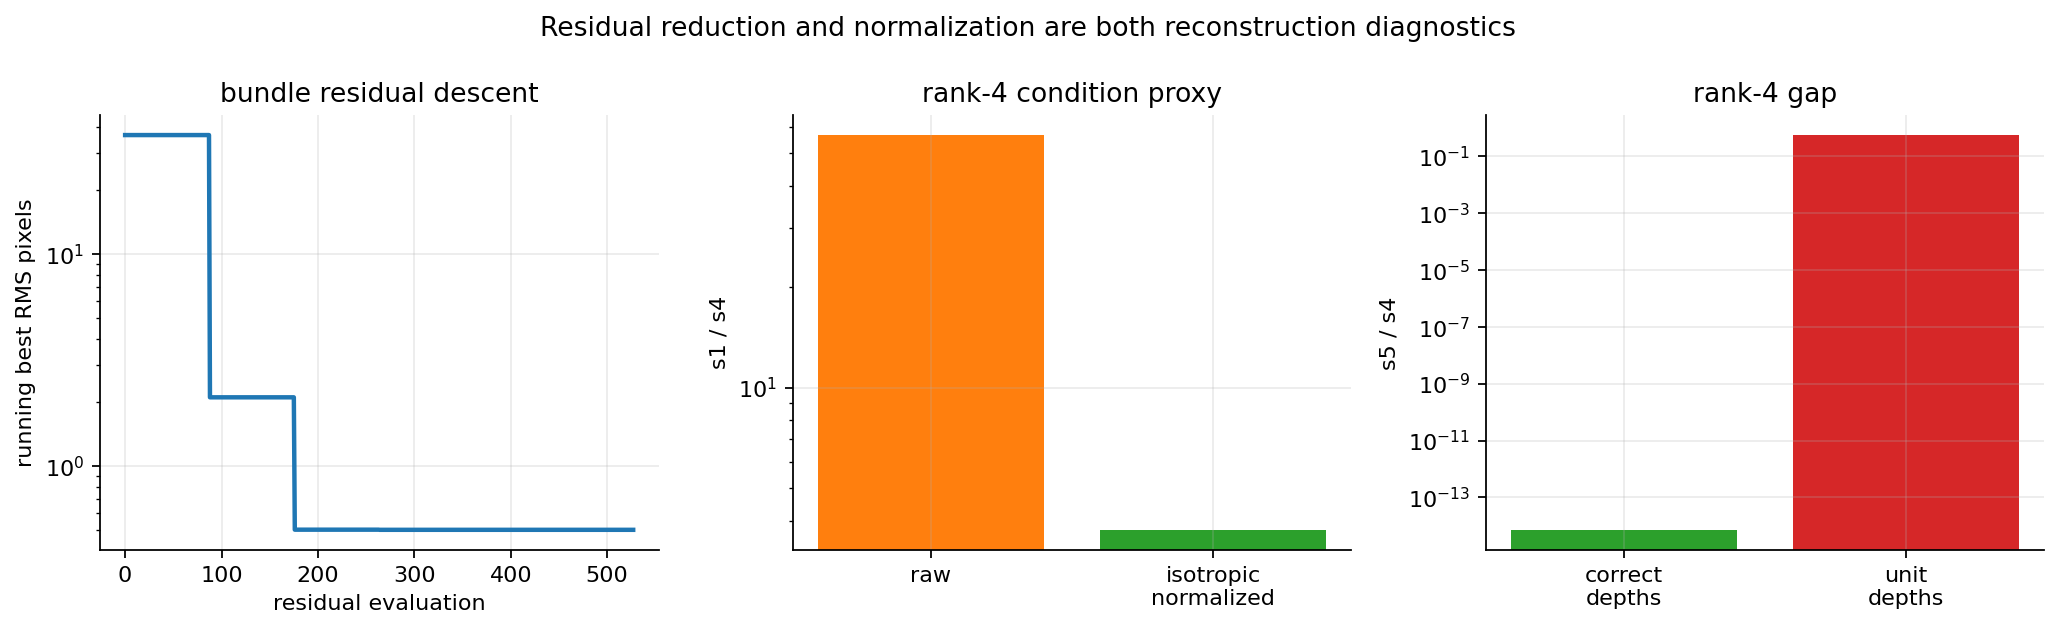

{'bundle_rms_reduction_factor': 72.77208993985839, 'projective_condition_reduction_factor': 15.059949320379376}


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
axes[0].plot(running_best_rms, color="#1f77b4", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_title("bundle residual descent")
axes[0].set_xlabel("residual evaluation")
axes[0].set_ylabel("running best RMS pixels")
axes[1].bar(["raw", "isotropic/nnormalized"], [condition_correct, condition_normalized], color=["#ff7f0e", "#2ca02c"])
axes[1].set_yscale("log")
axes[1].set_title("rank-4 condition proxy")
axes[1].set_ylabel("s1 / s4")
axes[2].bar(["correct/ndepths", "unit/ndepths"], [rank4_gap_correct, rank4_gap_unit], color=["#2ca02c", "#d62728"])
axes[2].set_yscale("log")
axes[2].set_title("rank-4 gap")
axes[2].set_ylabel("s5 / s4")
fig.suptitle("Residual reduction and normalization are both reconstruction diagnostics")
fig.tight_layout()
residual_path = save_fig(fig, "residual-descent-conditioning.png", width=940)

check_data["residual_descent_and_conditioning"] = {
    "bundle_rms_reduction_factor": float(rms_initial / rms_final),
    "projective_condition_reduction_factor": float(condition_correct / condition_normalized),
}
print(check_data["residual_descent_and_conditioning"])

## Plane-Based Projective Reconstruction: Known Homographies Leave Final Columns

If a reference plane induces known homographies from the first image to the other views, the left `3 x 3` block of each camera can be treated as known. The remaining unknowns are the final camera columns and the off-plane point coordinates. Eliminating the homogeneous image scale produces a linear homogeneous system. Its one-dimensional null-space is the expected common projective scale.

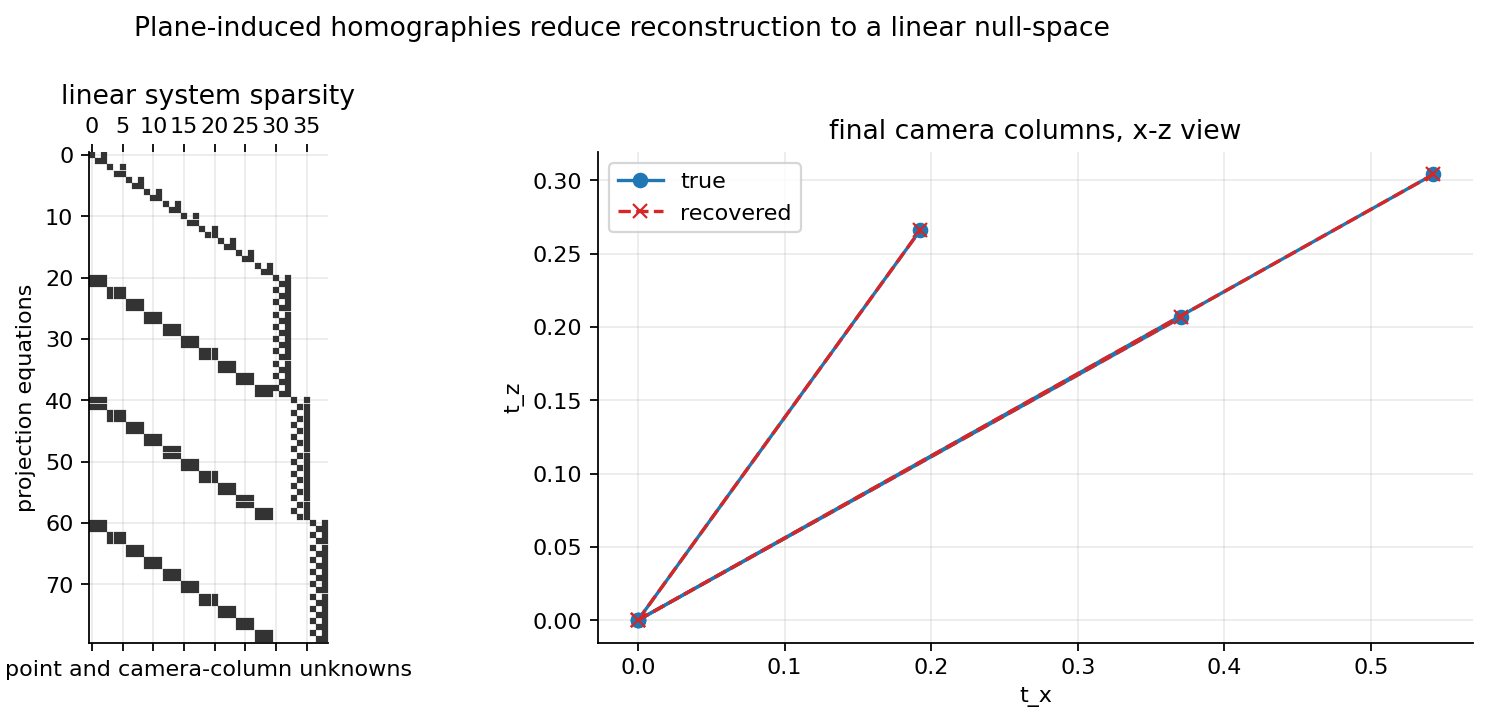

{'linear_system_shape': [80, 39], 'rank': 38, 'nullity': 1, 'relative_solution_error_after_scale_alignment': 2.7848556958908453e-15, 'smallest_singular_value': 1.1841742932895199e-15}


In [9]:
plane_rng = np.random.default_rng(1818)
plane_view_count = 4
plane_point_count = 10
known_blocks = [np.eye(3)]
true_final_columns = [np.zeros(3)]
for i in range(1, plane_view_count):
    block = np.eye(3) + plane_rng.normal(0.0, 0.12, size=(3, 3))
    block[2, :] *= 0.3
    block[2, 2] = 1.0 + plane_rng.normal(0.0, 0.03)
    known_blocks.append(block)
    true_final_columns.append(plane_rng.normal([0.2 * i, 0.05 * i, 0.3], [0.05, 0.04, 0.06]))
known_blocks = np.asarray(known_blocks)
true_final_columns = np.asarray(true_final_columns)
plane_points = plane_rng.uniform([-0.8, -0.5, 2.0], [0.8, 0.6, 4.0], size=(plane_point_count, 3))
plane_image_points = []
for i in range(plane_view_count):
    projected = plane_points @ known_blocks[i].T + true_final_columns[i]
    plane_image_points.append(projected[:, :2] / projected[:, 2:3])
plane_image_points = np.asarray(plane_image_points)

unknown_count = 3 * plane_point_count + 3 * (plane_view_count - 1)
system_rows = []
for i in range(plane_view_count):
    row1, row2, row3 = known_blocks[i]
    for j in range(plane_point_count):
        x, y = plane_image_points[i, j]
        row = np.zeros(unknown_count)
        row[3 * j:3 * j + 3] = x * row3 - row1
        if i > 0:
            offset = 3 * plane_point_count + 3 * (i - 1)
            row[offset:offset + 3] = [-1.0, 0.0, x]
        system_rows.append(row)
        row = np.zeros(unknown_count)
        row[3 * j:3 * j + 3] = y * row3 - row2
        if i > 0:
            offset = 3 * plane_point_count + 3 * (i - 1)
            row[offset:offset + 3] = [0.0, -1.0, y]
        system_rows.append(row)
plane_system = np.vstack(system_rows)
_, plane_singular, plane_vt = np.linalg.svd(plane_system)
plane_solution = plane_vt[-1]
plane_truth = np.r_[plane_points.ravel(), true_final_columns[1:].ravel()]
scale = float((plane_solution @ plane_truth) / (plane_solution @ plane_solution))
plane_solution_scaled = scale * plane_solution
plane_relative_error = float(np.linalg.norm(plane_solution_scaled - plane_truth) / np.linalg.norm(plane_truth))
plane_rank = int(np.sum(plane_singular > 1e-10))
plane_nullity = int(unknown_count - plane_rank)
recovered_final_columns = np.vstack([np.zeros(3), plane_solution_scaled[3 * plane_point_count:].reshape(plane_view_count - 1, 3)])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].spy(np.abs(plane_system) > 1e-12, markersize=2.0, color="#333333")
axes[0].set_title("linear system sparsity")
axes[0].set_xlabel("point and camera-column unknowns")
axes[0].set_ylabel("projection equations")
for i in range(1, plane_view_count):
    axes[1].plot([0, true_final_columns[i, 0]], [0, true_final_columns[i, 2]], "-o", color="#1f77b4", label="true" if i == 1 else None)
    axes[1].plot([0, recovered_final_columns[i, 0]], [0, recovered_final_columns[i, 2]], "--x", color="#d62728", label="recovered" if i == 1 else None)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("final camera columns, x-z view")
axes[1].set_xlabel("t_x")
axes[1].set_ylabel("t_z")
axes[1].legend()
fig.suptitle("Plane-induced homographies reduce reconstruction to a linear null-space")
fig.tight_layout()
plane_path = save_fig(fig, "plane-homography-translation-system.png", width=900)

check_data["plane_homography_reconstruction"] = {
    "linear_system_shape": [int(v) for v in plane_system.shape],
    "rank": plane_rank,
    "nullity": plane_nullity,
    "relative_solution_error_after_scale_alignment": plane_relative_error,
    "smallest_singular_value": float(plane_singular[-1]),
}
print(check_data["plane_homography_reconstruction"])

## Reconstruction From Sequences: Local Matches Must Become A Global Start

A video sequence supplies ordering and small baseline matches, but small baselines are weak for 3D structure. The initialization problem is therefore graph-shaped: pairwise matches are easy, triplets supply stronger geometry, and overlapping sub-sequences are merged before final bundle adjustment.

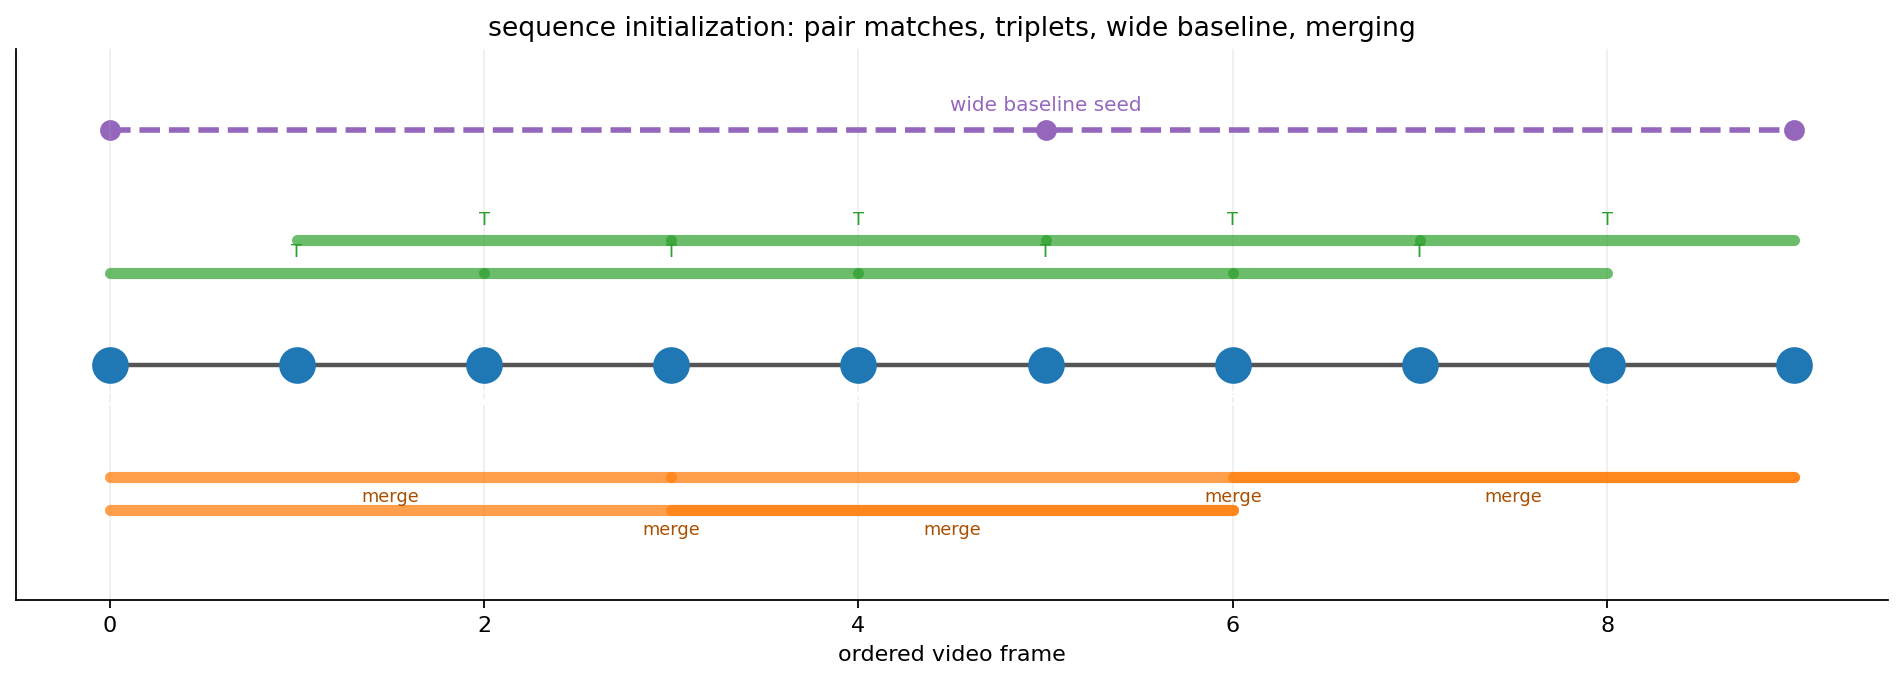

{'frame_count': 10, 'pair_graph_connected': True, 'minimum_neighboring_triplet_overlap': 2, 'triplet_count': 8}


In [10]:
frame_count = 10
frames = np.arange(frame_count)
pair_edges = [(i, i + 1) for i in range(frame_count - 1)]
triplets = [(i, i + 1, i + 2) for i in range(frame_count - 2)]
extended_baseline = [(0, frame_count // 2, frame_count - 1)]
merge_windows = [(0, 3), (3, 6), (6, 9), (0, 6), (3, 9)]
sequence_graph = nx.Graph()
sequence_graph.add_nodes_from(frames)
sequence_graph.add_edges_from(pair_edges)
triplet_overlap_sizes = [len(set(triplets[i]).intersection(triplets[i + 1])) for i in range(len(triplets) - 1)]

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.scatter(frames, np.zeros_like(frames), s=240, color="#1f77b4", zorder=3)
for frame in frames:
    ax.text(frame, -0.12, str(frame), ha="center", va="top", color="white", fontsize=9, fontweight="bold")
for i, j in pair_edges:
    ax.plot([i, j], [0, 0], color="#555555", linewidth=2, zorder=2)
for k, triplet in enumerate(triplets):
    y = 0.45 + 0.16 * (k % 2)
    ax.plot([triplet[0], triplet[-1]], [y, y], color="#2ca02c", linewidth=5, solid_capstyle="round", alpha=0.7)
    ax.text(np.mean(triplet), y + 0.08, "T", ha="center", fontsize=8, color="#2ca02c")
for a, b, c in extended_baseline:
    ax.plot([a, c], [1.15, 1.15], color="#9467bd", linewidth=2.5, linestyle="--")
    ax.scatter([a, b, c], [1.15, 1.15, 1.15], s=70, color="#9467bd")
    ax.text(b, 1.25, "wide baseline seed", ha="center", fontsize=9, color="#9467bd")
for k, (a, b) in enumerate(merge_windows):
    y = -0.55 - 0.16 * (k % 2)
    ax.plot([a, b], [y, y], color="#ff7f0e", linewidth=5, alpha=0.75, solid_capstyle="round")
    ax.text((a + b) / 2, y - 0.12, "merge", ha="center", fontsize=8, color="#aa4f00")
ax.set_ylim(-1.15, 1.55)
ax.set_xlim(-0.5, frame_count - 0.5)
ax.set_yticks([])
ax.set_xlabel("ordered video frame")
ax.set_title("sequence initialization: pair matches, triplets, wide baseline, merging")
ax.grid(axis="x", alpha=0.2)
fig.tight_layout()
sequence_path = save_fig(fig, "sequence-initialization-graph.png", width=940)

check_data["sequence_initialization"] = {
    "frame_count": int(frame_count),
    "pair_graph_connected": bool(nx.is_connected(sequence_graph)),
    "minimum_neighboring_triplet_overlap": int(min(triplet_overlap_sizes)),
    "triplet_count": int(len(triplets)),
}
print(check_data["sequence_initialization"])

## Applied Lab: Swap In Real Tracks

To use the same workflow on a small real sequence, keep the artifact contract rather than the synthetic data:

1. Track interest points frame to frame and store a visibility mask.
2. Use pair or triplet geometry to reject outliers before building a global observation graph.
3. Choose an initialization route: affine factorization for complete affine-like tracks, projective factorization if depths can be initialized, plane homographies if a reference plane is known, or hierarchical sequence merging for long videos.
4. Run bundle adjustment last and record both reprojection residuals and conditioning diagnostics.
5. Treat every reconstruction as projective until a metric upgrade, calibration constraint, or cheirality test has been stated explicitly.

## Final Sanity Checks

The checks below assert the chapter claims numerically: rank drops occur where the theory predicts, bundle adjustment reduces reprojection error, projective depth weighting matters, plane-based reconstruction has a one-dimensional scale ambiguity, and all concept-named artifacts exist with nonzero size.

In [11]:
alpha_i, beta_j, lambda_ij = symbols("alpha_i beta_j lambda_ij", nonzero=True)
scaled_depth_identity = simplify(alpha_i * beta_j * lambda_ij - (alpha_i * beta_j) * lambda_ij)
assert scaled_depth_identity == 0

assert check_data["bundle_adjustment"]["final_rms_pixels"] < 0.25 * check_data["bundle_adjustment"]["initial_rms_pixels"]
assert check_data["bundle_adjustment"]["normal_pattern_density"] < 0.25
assert check_data["affine_factorization"]["fourth_over_third_singular_value"] < 0.05
assert check_data["affine_factorization"]["rank3_relative_frobenius_error"] < 0.02
assert check_data["nonrigid_factorization"]["seventh_over_sixth_singular_value"] < 0.05
assert check_data["projective_factorization"]["correct_depth_fifth_over_fourth_singular_value"] < 1e-10
assert check_data["projective_factorization"]["unit_depth_fifth_over_fourth_singular_value"] > 0.1
assert check_data["projective_factorization"]["normalized_correct_depth_condition_s1_over_s4"] < check_data["projective_factorization"]["raw_correct_depth_condition_s1_over_s4"]
assert check_data["plane_homography_reconstruction"]["nullity"] == 1
assert check_data["plane_homography_reconstruction"]["relative_solution_error_after_scale_alignment"] < 1e-10
assert check_data["sequence_initialization"]["pair_graph_connected"]
assert check_data["sequence_initialization"]["minimum_neighboring_triplet_overlap"] == 2

artifact_names = [path.name for path in artifact_paths]
assert len(artifact_names) == len(set(artifact_names))
assert all(len(path.stem.split("-")) >= 2 or path.suffix == ".csv" for path in artifact_paths)

check_data["symbolic_depth_gauge_identity"] = str(scaled_depth_identity)
check_data["artifact_paths"] = [path.relative_to(BOOK_ROOT).as_posix() for path in artifact_paths]
final_sanity = check_data
checks_path = save_json(check_data, TOPIC, "checks", "n-view-computational-invariants.json")
artifact_paths.append(checks_path)
assert_artifacts(artifact_paths, min_bytes=64)
display_artifact(checks_path)

print("Validated artifacts:")
for path in artifact_paths:
    print("-", path.relative_to(BOOK_ROOT).as_posix(), path.stat().st_size, "bytes")

`artifacts/chapter-18/checks/n-view-computational-invariants.json`

Validated artifacts:
- artifacts/chapter-18/interactive/n-view-camera-track-scene.html 4860488 bytes
- artifacts/chapter-18/tables/bundle-adjustment-descent.csv 12425 bytes
- artifacts/chapter-18/figures/bundle-adjustment-sparse-normal.png 157884 bytes
- artifacts/chapter-18/figures/affine-factorization-rank-spectrum.png 133306 bytes
- artifacts/chapter-18/figures/nonrigid-subspace-mode-rank.png 138597 bytes
- artifacts/chapter-18/tables/projective-factorization-spectrum.csv 979 bytes
- artifacts/chapter-18/figures/projective-depth-factorization.png 107949 bytes
- artifacts/chapter-18/figures/residual-descent-conditioning.png 62460 bytes
- artifacts/chapter-18/figures/plane-homography-translation-system.png 96227 bytes
- artifacts/chapter-18/figures/sequence-initialization-graph.png 36244 bytes
- artifacts/chapter-18/checks/n-view-computational-invariants.json 2769 bytes


## Takeaways

- Bundle adjustment is best read as sparse nonlinear least squares on an observation graph.
- Affine factorization is powerful because centering reduces complete tracks to a rank-3 approximation problem.
- Non-rigid factorization preserves the subspace strategy but changes the expected rank and leaves a harder motion-recovery ambiguity.
- Projective factorization without useful depths is only an algebraic rank truncation; the depth weights and coordinate normalization decide whether it approximates image error.
- Plane homographies and sequence ordering are initialization devices. They do not replace final residual checks or the need to state the remaining projective, affine, or metric ambiguity.